## Cell 1 - Note

In [1]:
# ============================================================
# 05_kde_infer_aggregate.ipynb
# Final inference + confidence weighting + session aggregation
# ============================================================
#
# Inputs:
#   - pred_query.npz
#   - hybrid_transfer_best.keras
#
# Outputs:
#   - per_window_predictions.csv
#   - per_session_aggregation.csv
#   - infer_summary.json
#
# Notes:
#   - geometry comes from hybrid model outputs
#   - amplitude metadata is used for confidence weighting
#   - first version uses exponential score weighting
#   - can be upgraded later to true KDE + JS divergence
# ============================================================

## Cell 2 - Import

In [2]:
import os
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

2026-03-21 19:53:29.103619: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-21 19:53:29.110204: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774122809.117756  578221 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774122809.120016  578221 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774122809.125890  578221 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Cell 3 - Config

In [3]:
# ============================================================
# CONFIG
# ============================================================

DATA_ROOT = Path("/home/tonyliao/Location_AMP")   # change this
BUILD_DIR = DATA_ROOT / "dataset_build_hybrid"
TRANSFER_DIR = DATA_ROOT / "hybrid_transfer_runs"
OUT_DIR = DATA_ROOT / "hybrid_infer_runs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

PRED_QUERY_NPZ = BUILD_DIR / "pred_query.npz"
MODEL_PATH = TRANSFER_DIR / "hybrid_transfer_best.keras"
LABEL_MAP_JSON = BUILD_DIR / "label_map.json"

USE_AVECSI = True
TARGET_T = 256
TARGET_S = None

# confidence weighting
CONF_MODE = "exp_score"     # "exp_score" or "exp_margin"
ALPHA_SCORE = 2.0
ALPHA_MARGIN = 4.0
MIN_WEIGHT = 1e-4

# aggregation
SESSION_KEY = "loc_dir"     # aggregate by folder/session
USE_PRESENCE_FOR_WEIGHT = True
PRESENCE_POWER = 1.0

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Cell 4 - GPU Enable

In [4]:
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("memory growth warning:", e)

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 5 - Load Prediction

In [5]:
pred_query_obj = np.load(PRED_QUERY_NPZ, allow_pickle=True)
print("pred_query n =", len(pred_query_obj["label_id"]))

with open(LABEL_MAP_JSON, "r", encoding="utf-8") as f:
    label_meta = json.load(f)

label_map = label_meta["label_map"]
inv_label_map = {int(k): v for k, v in label_meta["inv_label_map"].items()}

NUM_CLASSES = len(label_map)
print("NUM_CLASSES =", NUM_CLASSES)
print(label_map)

pred_query n = 526
NUM_CLASSES = 9
{'Empty': 0, 'LeftDown': 1, 'LeftMid': 2, 'LeftUp': 3, 'MiddleDown': 4, 'MiddleUp': 5, 'RightDown': 6, 'RightMid': 7, 'RightUp': 8}


## Cell 6 - Helper

In [6]:
def np_load_float32(path):
    return np.load(str(path)).astype(np.float32)

def ensure_3d(x):
    x = np.asarray(x, dtype=np.float32)
    if x.ndim == 2:
        x = x[..., None]
    return x

def resize_to_target(x, target_t, target_s):
    x_tf = tf.convert_to_tensor(x, dtype=tf.float32)
    x_tf = tf.image.resize(x_tf, size=(target_t, target_s), method="bilinear")
    return x_tf.numpy().astype(np.float32)

def zscore_per_sample(x):
    mu = np.mean(x, axis=(0,1), keepdims=True)
    sd = np.std(x, axis=(0,1), keepdims=True) + 1e-6
    return ((x - mu) / sd).astype(np.float32)

def infer_target_s(npz_obj):
    a_amp = np_load_float32(npz_obj["A_amp_paths"][0])
    a_amp = ensure_3d(a_amp)
    return a_amp.shape[1]

if TARGET_S is None:
    TARGET_S = infer_target_s(pred_query_obj)

print("TARGET_T =", TARGET_T)
print("TARGET_S =", TARGET_S)

def build_amp_input_from_row(npz_obj, idx, use_avecsi=True):
    feats = []

    A = ensure_3d(np_load_float32(npz_obj["A_amp_paths"][idx]))
    B = ensure_3d(np_load_float32(npz_obj["B_amp_paths"][idx]))
    feats += [A, B]

    if use_avecsi:
        aavg_path = str(npz_obj["A_ampavg_paths"][idx])
        bavg_path = str(npz_obj["B_ampavg_paths"][idx])

        if aavg_path and bavg_path:
            Aavg = ensure_3d(np_load_float32(aavg_path))
            Bavg = ensure_3d(np_load_float32(bavg_path))

            Tref = A.shape[0]
            if Aavg.shape[0] == 1 and Tref > 1:
                Aavg = np.repeat(Aavg, Tref, axis=0)
            if Bavg.shape[0] == 1 and Tref > 1:
                Bavg = np.repeat(Bavg, Tref, axis=0)

            feats += [Aavg, Bavg]

    T0, S0 = feats[0].shape[:2]
    out = []
    for x in feats:
        if x.shape[0] != T0 or x.shape[1] != S0:
            x = resize_to_target(x, T0, S0)
        out.append(x)

    x = np.concatenate(out, axis=-1)
    x = resize_to_target(x, TARGET_T, TARGET_S)
    x = zscore_per_sample(x)
    return x.astype(np.float32)

def build_phase_input_from_row(npz_obj, idx):
    A = ensure_3d(np_load_float32(npz_obj["A_pha_paths"][idx]))
    B = ensure_3d(np_load_float32(npz_obj["B_pha_paths"][idx]))

    T0 = max(A.shape[0], B.shape[0])
    S0 = max(A.shape[1], B.shape[1])

    if A.shape[:2] != (T0, S0):
        A = resize_to_target(A, T0, S0)
    if B.shape[:2] != (T0, S0):
        B = resize_to_target(B, T0, S0)

    x = np.concatenate([A, B], axis=-1)
    x = resize_to_target(x, TARGET_T, TARGET_S)
    x = zscore_per_sample(x)
    return x.astype(np.float32)

CLASS_CENTER_MAP = {
    "Empty":       [0.0, 0.0],
    "LeftDown":    [2.0, 6.0],
    "LeftMid":     [2.0, 4.0],
    "LeftUp":      [2.0, 2.0],
    "MiddleDown":  [3.0, 0.0],
    "MiddleUp":    [3.0, 2.0],
    "RightDown":   [4.0, 6.0],
    "RightMid":    [4.0, 4.0],
    "RightUp":     [4.0, 2.0],
}

def get_xy_from_label_name(label_name):
    return np.asarray(CLASS_CENTER_MAP[str(label_name)], dtype=np.float32)

TARGET_T = 256
TARGET_S = 41


## Cell 7 - Load Model 

In [7]:
model = keras.models.load_model(
    MODEL_PATH,
    compile=False,
    safe_mode=False,
)

print("Loaded model:", MODEL_PATH)
model.summary()

I0000 00:00:1774122810.308109  578221 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20718 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


Loaded model: /home/tonyliao/Location_AMP/hybrid_transfer_runs/hybrid_transfer_best.keras


Model: "hybrid_aoa_amp_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ amp_in (InputLayer) │ (None, 256, 41,   │          0 │ -                 │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ amp_ssl_encoder     │ (None, 256)       │  1,308,160 │ amp_in[0][0]      │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pha_in (InputLayer) │ (None, 256, 41,   │          0 │ -                 │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ amp_feat (Dense)    │ (None, 128)       │     32,896 │ amp_ssl_encoder[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phase_geometry_enc… │ (None, 128)       │  1,274,112 │ pha_in[0][0]      │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ amp_feat[0][0],   │
│ (Concatenate)       │                   │            │ phase_geometry_e… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_out (Dense)   │ (None, 9)         │      1,161 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ presence_out        │ (None, 1)         │        129 │ amp_feat[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     16,512 │ amp_feat[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 266)       │          0 │ amp_feat[0][0],   │
│ (Concatenate)       │                   │            │ phase_geometry_e… │
│                     │                   │            │ presence_out[0][… │
│                     │                   │            │ class_out[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 2)         │        258 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │     17,088 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ amp_delta_out       │ (None, 2)         │          0 │ dense_4[0][0]     │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ phase_geometry_e… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ delta_gate (Dense)  │ (None, 1)         │         65 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aoa_xy_out (Dense)  │ (None, 2)         │        258 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 2)         │          0 │ amp_delta_out[0]… │
│                     │                   │            │ delta_gate[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final_xy_out (Add)  │ (None, 2)         │          0 │ aoa_xy_out[0][0], │
│                     │                   │            │ multiply[0][0]  

 Total params: 2,700,047 (10.30 MB)

 Trainable params: 34,181 (133.52 KB)

 Non-trainable params: 2,665,866 (10.17 MB)

## Cell 8 - Prediction Helper

In [8]:
def softmax_margin(prob):
    prob = np.asarray(prob, dtype=np.float32)
    if prob.ndim != 1:
        prob = prob.reshape(-1)

    if len(prob) < 2:
        return 0.0

    top2 = np.sort(prob)[-2:]
    return float(top2[-1] - top2[-2])

def get_scalar_meta(npz_obj, key, idx, default=np.nan):
    if key in npz_obj.files:
        return float(npz_obj[key][idx])
    return default

def compute_confidence_weight(npz_obj, idx, pred_dict):
    """
    First practical weighting version:
    1) exp_score: use window quality score + presence
    2) exp_margin: use classifier margin + presence
    """
    presence = float(pred_dict["presence"])
    class_prob = np.asarray(pred_dict["class_prob"], dtype=np.float32)

    if CONF_MODE == "exp_score":
        a_score = get_scalar_meta(npz_obj, "A_win_score", idx, default=0.0)
        b_score = get_scalar_meta(npz_obj, "B_win_score", idx, default=0.0)
        score = 0.5 * (a_score + b_score)
        w = math.exp(ALPHA_SCORE * score)

    elif CONF_MODE == "exp_margin":
        margin = softmax_margin(class_prob)
        w = math.exp(ALPHA_MARGIN * margin)

    else:
        w = 1.0

    if USE_PRESENCE_FOR_WEIGHT:
        w *= max(presence, 1e-3) ** PRESENCE_POWER

    return max(float(w), MIN_WEIGHT)

def predict_one(npz_obj, idx, model):
    amp = build_amp_input_from_row(npz_obj, idx, use_avecsi=USE_AVECSI)
    pha = build_phase_input_from_row(npz_obj, idx)

    x = {
        "amp_in": np.expand_dims(amp, axis=0),
        "pha_in": np.expand_dims(pha, axis=0),
    }

    pred = model.predict(x, verbose=0)

    out = {
        "presence": float(pred["presence_out"][0,0]),
        "class_prob": pred["class_out"][0].astype(np.float32),
        "class_id": int(np.argmax(pred["class_out"][0])),
        "class_name": inv_label_map[int(np.argmax(pred["class_out"][0]))],
        "aoa_xy": pred["aoa_xy_out"][0].astype(np.float32),
        "amp_delta": pred["amp_delta_out"][0].astype(np.float32),
        "final_xy": pred["final_xy_out"][0].astype(np.float32),
    }
    return out

example = predict_one(pred_query_obj, 0, model)
for k, v in example.items():
    print(k, v)

I0000 00:00:1774122811.012675  578352 service.cc:152] XLA service 0x7f60a801acd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774122811.012689  578352 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-03-21 19:53:31.019590: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774122811.116068  578352 cuda_dnn.cc:529] Loaded cuDNN version 90300


presence 0.998313307762146
class_prob [6.5045012e-04 8.9081546e-04 3.6455920e-05 9.9669468e-01 8.8598119e-04
 1.4040066e-04 1.3954593e-04 4.0220455e-04 1.5953281e-04]
class_id 3
class_name LeftUp
aoa_xy [1.8425078 2.0197139]
amp_delta [-0.3847801   0.16584416]
final_xy [1.8332119 2.0237205]


I0000 00:00:1774122812.308584  578352 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


## Cell 9 - Per-Window Prediction + Confidence Weighting

In [9]:
rows = []
n = len(pred_query_obj["label_id"])

for i in range(n):
    pred = predict_one(pred_query_obj, i, model)
    w = compute_confidence_weight(pred_query_obj, i, pred)

    true_label_id = int(pred_query_obj["label_id"][i])
    true_label_name = str(pred_query_obj["label_name"][i])
    true_xy = get_xy_from_label_name(true_label_name)

    pred_xy = np.asarray(pred["final_xy"], dtype=np.float32)
    aoa_xy = np.asarray(pred["aoa_xy"], dtype=np.float32)
    amp_delta = np.asarray(pred["amp_delta"], dtype=np.float32)

    err_final = float(np.linalg.norm(true_xy - pred_xy))
    err_aoa = float(np.linalg.norm(true_xy - aoa_xy))

    rows.append({
        "idx": i,
        "domain": str(pred_query_obj["domain"][i]) if "domain" in pred_query_obj.files else "pred",
        "loc_dir": str(pred_query_obj["loc_dir"][i]) if "loc_dir" in pred_query_obj.files else "",
        "pair_id": str(pred_query_obj["pair_id"][i]) if "pair_id" in pred_query_obj.files else str(i),

        "true_label_id": true_label_id,
        "true_label_name": true_label_name,
        "pred_label_id": int(pred["class_id"]),
        "pred_label_name": str(pred["class_name"]),

        "presence": float(pred["presence"]),
        "weight": float(w),

        "true_x": float(true_xy[0]),
        "true_y": float(true_xy[1]),

        "aoa_x": float(aoa_xy[0]),
        "aoa_y": float(aoa_xy[1]),

        "delta_x": float(amp_delta[0]),
        "delta_y": float(amp_delta[1]),

        "final_x": float(pred_xy[0]),
        "final_y": float(pred_xy[1]),

        "err_aoa": err_aoa,
        "err_final": err_final,

        "A_win_score": get_scalar_meta(pred_query_obj, "A_win_score", i, default=np.nan),
        "B_win_score": get_scalar_meta(pred_query_obj, "B_win_score", i, default=np.nan),
        "A_amp_std": get_scalar_meta(pred_query_obj, "A_amp_std", i, default=np.nan),
        "B_amp_std": get_scalar_meta(pred_query_obj, "B_amp_std", i, default=np.nan),
    })

df_win = pd.DataFrame(rows)
print(df_win.shape)
display(df_win.head())

per_window_csv = OUT_DIR / "per_window_predictions.csv"
df_win.to_csv(per_window_csv, index=False)
print("saved:", per_window_csv)

(526, 24)


,idx,domain,loc_dir,pair_id,true_label_id,true_label_name,pred_label_id,pred_label_name,presence,weight,...,delta_x,delta_y,final_x,final_y,err_aoa,err_final,A_win_score,B_win_score,A_amp_std,B_amp_std
0,0,pred,/home/tonyliao/Location_AMP/Pred/LeftUp_Pred,00145,3,LeftUp,3,LeftUp,0.998313,3.397029,...,-0.384780,0.165844,1.833212,2.023721,0.158721,0.168466,0.603923,0.620666,3.251952,3.286997
1,1,pred,/home/tonyliao/Location_AMP/Pred/LeftUp_Pred,00141,3,LeftUp,3,LeftUp,0.997316,3.358069,...,-0.385541,-0.011899,1.780130,1.964582,0.211373,0.222704,0.609536,0.604517,2.655789,5.655301
2,2,pred,/home/tonyliao/Location_AMP/Pred/Empty_Pred,00065,0,Empty,0,Empty,0.006408,0.023903,...,0.016850,0.138454,0.074843,0.043570,0.086327,0.086602,0.732625,0.583835,5.917001,1.908609
3,3,pred,/home/tonyliao/Location_AMP/Pred/LeftDown_Far,00121,1,LeftDown,1,LeftDown,0.999999,3.419200,...,-0.546223,-0.460799,2.043960,5.508387,0.492632,0.493575,0.513808,0.715599,1.440865,4.197965
4,4,pred,/home/tonyliao/Location_AMP/Pred/Empty_Pred,00018,0,Empty,0,Empty,0.007360,0.024669,...,-0.102415,-0.068241,0.061709,0.108266,0.125236,0.124618,0.614962,0.594575,2.424862,1.596729


saved: /home/tonyliao/Location_AMP/hybrid_infer_runs/per_window_predictions.csv


## Cell 10 - Session Aggregation Helper

In [10]:
# session-level aggregation

def weighted_xy(group_df):
    w = group_df["weight"].values.astype(np.float64)
    x = group_df["final_x"].values.astype(np.float64)
    y = group_df["final_y"].values.astype(np.float64)

    ws = np.sum(w)
    if ws <= 0:
        return float(np.mean(x)), float(np.mean(y))
    return float(np.sum(w * x) / ws), float(np.sum(w * y) / ws)

def unweighted_xy(group_df):
    return float(group_df["final_x"].mean()), float(group_df["final_y"].mean())

def majority_vote_label(group_df):
    return group_df["pred_label_name"].value_counts().idxmax()


## Cell 11 - Aggregation Weighting

In [11]:
session_rows = []

for key, g in df_win.groupby(SESSION_KEY):
    true_label_name = g["true_label_name"].mode().iloc[0]
    true_xy = np.array([g["true_x"].iloc[0], g["true_y"].iloc[0]], dtype=np.float32)

    ux, uy = unweighted_xy(g)
    wx, wy = weighted_xy(g)

    err_unweighted = float(np.linalg.norm(true_xy - np.array([ux, uy], dtype=np.float32)))
    err_weighted   = float(np.linalg.norm(true_xy - np.array([wx, wy], dtype=np.float32)))

    session_rows.append({
        SESSION_KEY: key,
        "n_windows": int(len(g)),
        "true_label_name": true_label_name,

        "unweighted_x": ux,
        "unweighted_y": uy,
        "weighted_x": wx,
        "weighted_y": wy,

        "pred_label_majority": majority_vote_label(g),

        "err_unweighted": err_unweighted,
        "err_weighted": err_weighted,

        "mean_presence": float(g["presence"].mean()),
        "mean_weight": float(g["weight"].mean()),
        "mean_err_final": float(g["err_final"].mean()),
        "mean_err_aoa": float(g["err_aoa"].mean()),
    })

df_sess = pd.DataFrame(session_rows)
print(df_sess.shape)
display(df_sess.head())

per_session_csv = OUT_DIR / "per_session_aggregation.csv"
df_sess.to_csv(per_session_csv, index=False)
print("saved:", per_session_csv)

(4, 14)


,loc_dir,n_windows,true_label_name,unweighted_x,unweighted_y,weighted_x,weighted_y,pred_label_majority,err_unweighted,err_weighted,mean_presence,mean_weight,mean_err_final,mean_err_aoa
0,/home/tonyliao/Location_AMP/Pred/Empty_Pred,127,Empty,0.068633,0.158496,0.073854,0.164363,Empty,0.172718,0.180193,0.009498,0.032505,0.177268,0.177229
1,/home/tonyliao/Location_AMP/Pred/LeftDown_Far,127,LeftDown,2.008015,5.873713,2.007051,5.869876,LeftDown,0.126542,0.130314,0.999867,3.557243,0.181940,0.181844
2,/home/tonyliao/Location_AMP/Pred/LeftUp_Near,134,LeftUp,1.922088,1.948150,1.921210,1.947541,LeftUp,0.093588,0.094656,0.998160,3.597070,0.125908,0.126375
3,/home/tonyliao/Location_AMP/Pred/LeftUp_Pred,138,LeftUp,1.861546,1.991102,1.862830,1.991021,LeftUp,0.138739,0.137463,0.985764,3.382217,0.158536,0.156905


saved: /home/tonyliao/Location_AMP/hybrid_infer_runs/per_session_aggregation.csv


## Cell 13 - Summary

In [12]:
window_cls_acc = float((df_win["true_label_id"] == df_win["pred_label_id"]).mean())
window_mean_err = float(df_win["err_final"].mean())
window_median_err = float(df_win["err_final"].median())

session_mean_err_unweighted = float(df_sess["err_unweighted"].mean())
session_median_err_unweighted = float(df_sess["err_unweighted"].median())

session_mean_err_weighted = float(df_sess["err_weighted"].mean())
session_median_err_weighted = float(df_sess["err_weighted"].median())

summary = {
    "n_windows": int(len(df_win)),
    "n_sessions": int(len(df_sess)),
    "window_class_acc": window_cls_acc,
    "window_mean_err_final": window_mean_err,
    "window_median_err_final": window_median_err,
    "session_mean_err_unweighted": session_mean_err_unweighted,
    "session_median_err_unweighted": session_median_err_unweighted,
    "session_mean_err_weighted": session_mean_err_weighted,
    "session_median_err_weighted": session_median_err_weighted,
    "conf_mode": CONF_MODE,
    "alpha_score": ALPHA_SCORE,
    "alpha_margin": ALPHA_MARGIN,
    "use_presence_for_weight": USE_PRESENCE_FOR_WEIGHT,
    "presence_power": PRESENCE_POWER,
}

print(json.dumps(summary, indent=2))
with open(OUT_DIR / "infer_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("saved:", OUT_DIR / "infer_summary.json")

{
  "n_windows": 526,
  "n_sessions": 4,
  "window_class_acc": 1.0,
  "window_mean_err_final": 0.16039749026341016,
  "window_median_err_final": 0.1403806358575821,
  "session_mean_err_unweighted": 0.13289674185216427,
  "session_median_err_unweighted": 0.13264036923646927,
  "session_mean_err_weighted": 0.13565675541758537,
  "session_median_err_weighted": 0.13388888537883759,
  "conf_mode": "exp_score",
  "alpha_score": 2.0,
  "alpha_margin": 4.0,
  "use_presence_for_weight": true,
  "presence_power": 1.0
}
saved: /home/tonyliao/Location_AMP/hybrid_infer_runs/infer_summary.json


## Cell 14 - Result

In [13]:
print("Window-level metrics")
print("  class acc         :", window_cls_acc)
print("  mean final error  :", window_mean_err)
print("  median final error:", window_median_err)

print("\nSession-level metrics")
print("  unweighted mean   :", session_mean_err_unweighted)
print("  unweighted median :", session_median_err_unweighted)
print("  weighted mean     :", session_mean_err_weighted)
print("  weighted median   :", session_median_err_weighted)

# optional quick comparison table
compare_df = df_sess[[
    SESSION_KEY,
    "true_label_name",
    "n_windows",
    "err_unweighted",
    "err_weighted",
    "mean_presence",
    "mean_weight",
]].copy()

compare_df = compare_df.sort_values(by="err_weighted", ascending=True).reset_index(drop=True)
display(compare_df)

Window-level metrics
  class acc         : 1.0
  mean final error  : 0.16039749026341016
  median final error: 0.1403806358575821

Session-level metrics
  unweighted mean   : 0.13289674185216427
  unweighted median : 0.13264036923646927
  weighted mean     : 0.13565675541758537
  weighted median   : 0.13388888537883759


,loc_dir,true_label_name,n_windows,err_unweighted,err_weighted,mean_presence,mean_weight
0,/home/tonyliao/Location_AMP/Pred/LeftUp_Near,LeftUp,134,0.093588,0.094656,0.998160,3.597070
1,/home/tonyliao/Location_AMP/Pred/LeftDown_Far,LeftDown,127,0.126542,0.130314,0.999867,3.557243
2,/home/tonyliao/Location_AMP/Pred/LeftUp_Pred,LeftUp,138,0.138739,0.137463,0.985764,3.382217
3,/home/tonyliao/Location_AMP/Pred/Empty_Pred,Empty,127,0.172718,0.180193,0.009498,0.032505


## Cell 15 - Plot

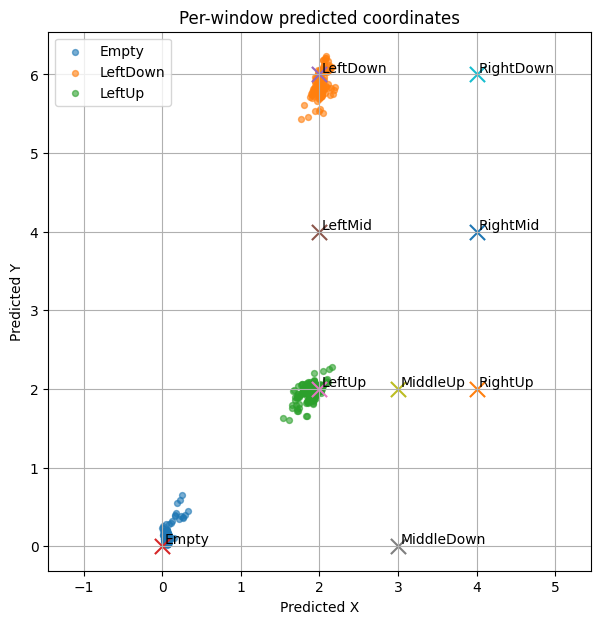

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# df_win must already exist
plt.figure(figsize=(7, 7))

for label_name, g in df_win.groupby("true_label_name"):
    plt.scatter(
        g["final_x"],
        g["final_y"],
        s=18,
        alpha=0.6,
        label=label_name
    )

# true anchor centers
for name, xy in CLASS_CENTER_MAP.items():
    plt.scatter(xy[0], xy[1], marker="x", s=120)
    plt.text(xy[0] + 0.03, xy[1] + 0.03, name)

plt.xlabel("Predicted X")
plt.ylabel("Predicted Y")
plt.title("Per-window predicted coordinates")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

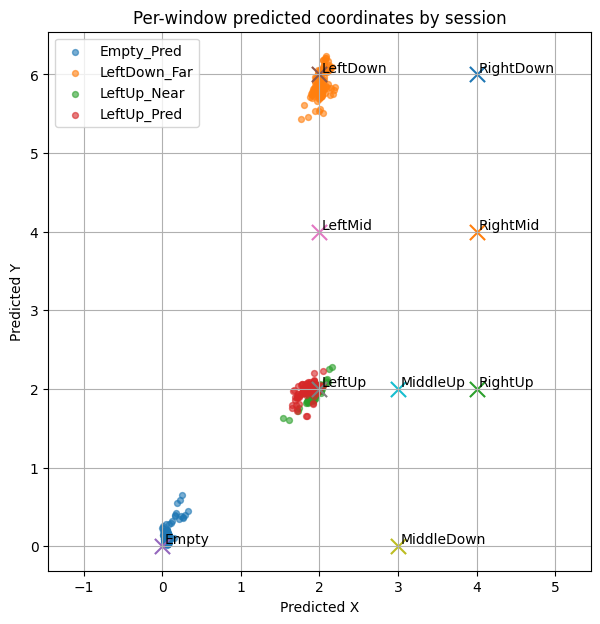

In [15]:
plt.figure(figsize=(7, 7))

for loc_dir, g in df_win.groupby("loc_dir"):
    short_name = Path(loc_dir).name
    plt.scatter(
        g["final_x"],
        g["final_y"],
        s=18,
        alpha=0.6,
        label=short_name
    )

for name, xy in CLASS_CENTER_MAP.items():
    plt.scatter(xy[0], xy[1], marker="x", s=120)
    plt.text(xy[0] + 0.03, xy[1] + 0.03, name)

plt.xlabel("Predicted X")
plt.ylabel("Predicted Y")
plt.title("Per-window predicted coordinates by session")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

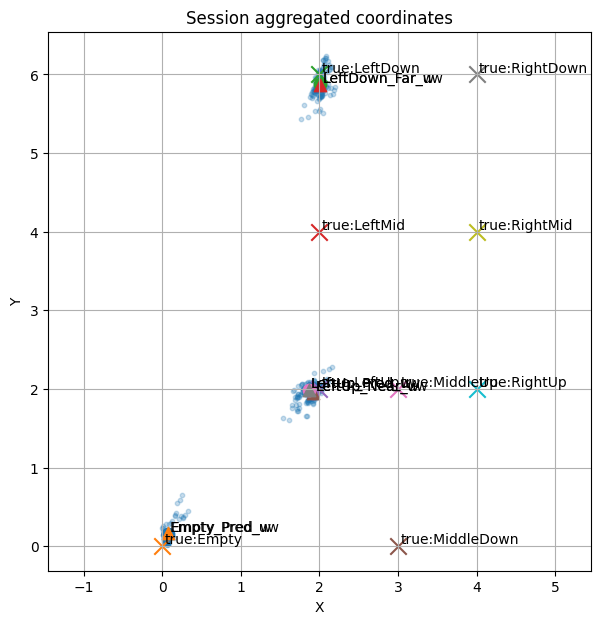

In [16]:
plt.figure(figsize=(7, 7))

# per-window points
plt.scatter(df_win["final_x"], df_win["final_y"], s=10, alpha=0.25)

# true centers
for name, xy in CLASS_CENTER_MAP.items():
    plt.scatter(xy[0], xy[1], marker="x", s=140)
    plt.text(xy[0] + 0.03, xy[1] + 0.03, f"true:{name}")

# session aggregated points
for _, row in df_sess.iterrows():
    short_name = Path(row["loc_dir"]).name

    plt.scatter(row["unweighted_x"], row["unweighted_y"], s=80, marker="o")
    plt.text(row["unweighted_x"] + 0.03, row["unweighted_y"] + 0.03, f"{short_name}_uw")

    plt.scatter(row["weighted_x"], row["weighted_y"], s=80, marker="^")
    plt.text(row["weighted_x"] + 0.03, row["weighted_y"] + 0.03, f"{short_name}_w")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Session aggregated coordinates")
plt.grid(True)
plt.axis("equal")
plt.show()

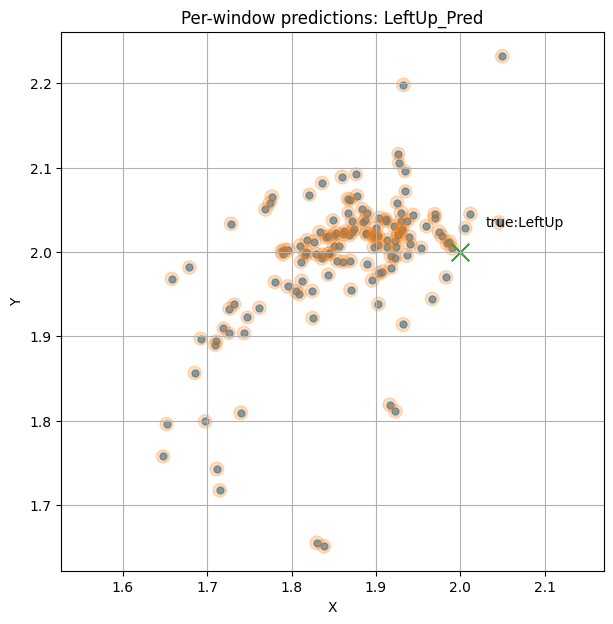

In [17]:
# == optional: visualize one session in detail ==
session_name = "LeftUp_Pred"
g = df_win[df_win["loc_dir"].str.endswith(session_name)].copy()

plt.figure(figsize=(7, 7))

plt.scatter(
    g["final_x"],
    g["final_y"],
    s=25,
    alpha=0.7
)

# weight-scaled points
plt.scatter(
    g["final_x"],
    g["final_y"],
    s=20 + 80 * (g["weight"] / g["weight"].max()),
    alpha=0.25
)

true_name = g["true_label_name"].iloc[0]
true_xy = CLASS_CENTER_MAP[true_name]

plt.scatter(true_xy[0], true_xy[1], marker="x", s=160)
plt.text(true_xy[0] + 0.03, true_xy[1] + 0.03, f"true:{true_name}")

plt.xlabel("X")
plt.ylabel("Y")
plt.title(f"Per-window predictions: {session_name}")
plt.grid(True)
plt.axis("equal")
plt.show()

In [ ]:
import tensorflow as tf
tf.keras.backend.clear_session()
#Restart the kernel to free memory
import IPython
app = IPython.get_ipython()
app.kernel.do_shutdown(True)  # True = restart, False = shutdown

{'status': 'ok', 'restart': True}

: 